In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/salary_benchmark.csv')


df_copy = df.copy()

df_copy = df_copy.drop(columns=['employee_id']).drop_duplicates()

In [3]:

#copy paste from 01_eda.ipynb
fix_cols = ['job_title', 'education_level', 'seniority_level']
for col in fix_cols:
    df[col] = df[col].str.strip().str.title()

value_map = {
    "Ml Engineer": "ML Engineer",
    "Hr Specialist": "HR Specialist",
    "Bachelor'S": "Bachelor",
    "Bachelors": "Bachelor",
    "Master'S": "Master",
    "Masters": "Master",
    "Mba": "MBA", 
    "Associate'S": "Associate",
    "Ph.D.": "PhD",
    "Phd": "PhD",
    "Doctorate": "PhD",
    "Mid-Level": "Mid"
}

for col in fix_cols:
    df[col] = df[col].replace(value_map)

## Impute

In [4]:
new_hire = df['years_at_company'] < 1 
df_copy.loc[new_hire & df['performance_rating'].isnull(), 'performance_rating'] = 3.0
df_copy['performance_rating'] = df_copy['performance_rating'].fillna(df_copy['performance_rating'].median())

df_copy['num_certifications'] = df_copy.groupby('job_title')['num_certifications'].transform(
    lambda x: x.fillna(x.median())
)

df_copy['years_experience'] = df_copy.groupby('seniority_level')['years_experience'].transform(
    lambda x: x.fillna(x.median())
)

print("Remaining Missing Values:", df_copy.isnull().sum().sum())

Remaining Missing Values: 0


In [ ]:
invalid_experience = df_copy['years_experience'] > (df_copy['age'] - 18)
df_copy.loc[invalid_experience, 'years_experience'] = df_copy.loc[invalid_experience, 'age'] - 18

invalid_works = df_copy['years_at_company'] > df_copy['years_experience']
df_copy.loc[invalid_works, 'years_at_company'] = df_copy.loc[invalid_works, 'years_experience']

df_copy = df_copy[df_copy['base_salary'] >= 33000].copy()


print(f"Cleaned Dataset Shape: {df_copy.shape}")
# df_copy['company_size'] = df_copy['company_size'].str.strip()
print(df_copy['company_size'].value_counts())


Cleaned Dataset Shape: (5500, 19)
company_size
Large (1000-5000)     1411
Mid (200-1000)        1331
Enterprise (5000+)    1092
Small (50-200)         988
Startup (<50)          678
Name: count, dtype: int64
education_level
Bachelor's     2286
Master's       1294
Associate's     539
MBA             507
High School     434
PhD             353
BACHELOR'S       14
bachelor's       14
Master           13
phd              11
Bachelors        11
mba              10
masters           9
PHD               5
Name: count, dtype: int64


In [12]:
for col in fix_cols:
    df_copy[col] = df_copy[col].str.strip().str.title()
    print(f"Unique values in {col}: {df_copy[col].value_counts().index.tolist()}")
    
value_map = {
    "Ml Engineer": "ML Engineer",
    "Hr Specialist": "HR Specialist",
    
    "Bachelor'S": "Bachelor",
    "Bachelors": "Bachelor",
    
    "Master'S": "Master",
    "Masters": "Master",
    "Mba": "MBA", 
    
    "Associate'S": "Associate",
    
    "Ph.D.": "PhD",
    "Phd": "PhD",
    "Doctorate": "PhD",
    
    "Mid-Level": "Mid"
}

for col in fix_cols:
    df_copy[col] = df_copy[col].replace(value_map)
    
for col in fix_cols:
    col_values = df_copy[col].value_counts()
    print(f"Cleaned unique values in {col}: {col_values.index.tolist()}")

Unique values in job_title: ['Software Engineer', 'Data Analyst', 'Data Scientist', 'Ml Engineer', 'Business Analyst', 'Finance Analyst', 'Devops Engineer', 'Product Manager', 'Marketing Analyst', 'Hr Specialist']
Unique values in education_level: ["Bachelor'S", "Master'S", "Associate'S", 'Mba', 'High School', 'Phd', 'Master', 'Bachelors', 'Masters']
Unique values in seniority_level: ['Mid', 'Senior', 'Junior', 'Lead', 'Principal', 'Mid-Level']
Cleaned unique values in job_title: ['Software Engineer', 'Data Analyst', 'Data Scientist', 'ML Engineer', 'Business Analyst', 'Finance Analyst', 'Devops Engineer', 'Product Manager', 'Marketing Analyst', 'HR Specialist']
Cleaned unique values in education_level: ['Bachelor', 'Master', 'Associate', 'MBA', 'High School', 'PhD']
Cleaned unique values in seniority_level: ['Mid', 'Senior', 'Junior', 'Lead', 'Principal']


In [14]:
print(f"Cleaned Dataset Shape: {df_copy.shape}")
# df_copy['company_size'] = df_copy['company_size'].str.strip()
print(df_copy['company_size'].value_counts())
display(df_copy['education_level'].value_counts())

Cleaned Dataset Shape: (5500, 19)
company_size
Large (1000-5000)     1411
Mid (200-1000)        1331
Enterprise (5000+)    1092
Small (50-200)         988
Startup (<50)          678
Name: count, dtype: int64


education_level
Bachelor       2325
Master         1316
Associate       539
MBA             517
High School     434
PhD             369
Name: count, dtype: int64

In [22]:
seniority_map = {'Junior': 1, 'Mid': 2, 'Senior': 3, 'Lead': 4, 'Principal': 5}
df_copy['seniority_ordinal'] = df_copy['seniority_level'].map(seniority_map)

# Map Education
education_map = {
    'High School': 1, 
    'Associate': 2, 
    'Bachelor': 3, 
    'Master': 4, 
    'MBA': 5, 
    'PhD': 6
}
df_copy['education_ordinal'] = df_copy['education_level'].map(education_map)

size_map = {
    'Startup (<50)': 1,
    'Small (50-200)': 2,
    'Mid (200-1000)': 3,
    'Large (1000-5000)': 4,
    'Enterprise (5000+)': 5
}
if 'company_size' in df_copy.columns:
    # Just in case there's an issue with leading spaces from earlier
    df_copy['company_size'] = df_copy['company_size'].str.strip()
    df_copy['company_size_ordinal'] = df_copy['company_size'].map(size_map)

# display(df_copy['seniority_ordinal'].value_counts().sum())
# display(df_copy['education_ordinal'].value_counts().sum())

## FEATURE ENGINEERING

In [ ]:
df_copy['experience_x_seniority'] = df_copy['years_experience'] * df_copy['seniority_ordinal']
df_copy['tenure_ratio'] = np.where(df_copy['years_experience'] == 0, 0, df_copy['years_at_company'] / df_copy['years_experience'])

df_copy['promotion_rate'] = df_copy['num_promotions'] / df_copy['years_at_company'].clip(lower=1)

df_copy['is_tech_or_finance'] = df_copy['industry'].isin(['Tech', 'Finance']).astype(int)
df_copy['is_high_col'] = (df_copy['col_index'] > 1.15).astype(int)
df_copy['col_x_experience'] = df_copy['col_index'] * df_copy['years_experience']

df_copy['is_new_hire'] = (df_copy['years_at_company'] < 1).astype(int)

is_high_edu = df_copy['education_ordinal'] >= 5
is_low_seniority = df_copy['seniority_ordinal'] <= 2
df_copy['is_overqualified'] = (is_high_edu & is_low_seniority).astype(int)

df_copy['has_certifications'] = (df_copy['num_certifications'] > 0).astype(int)


display(df_copy.head())

,age,gender,education_level,job_title,seniority_level,years_experience,years_at_company,industry,company_size,location,...,company_size_ordinal,experience_x_seniority,tenure_ratio,promotion_rate,is_tech_or_finance,is_high_col,col_x_experience,is_new_hire,is_overqualified,has_certifications
0,26,Male,PhD,Data Scientist,Mid,0.4,0.4,Finance,Enterprise (5000+),Boston,...,5,0.8,1.000000,1.000000,1,1,0.472,1,1,1
1,21,Male,Bachelor,Devops Engineer,Mid,3.0,0.8,Tech,Startup (<50),Remote,...,1,6.0,0.266667,2.000000,1,0,3.000,1,0,1
2,32,Female,MBA,Devops Engineer,Principal,14.0,3.8,Tech,Mid (200-1000),New York,...,3,70.0,0.271429,0.000000,1,1,18.480,0,0,0
3,26,Male,High School,Finance Analyst,Mid,0.4,0.4,Government,Mid (200-1000),Denver,...,3,0.8,1.000000,0.000000,0,0,0.424,1,0,1
4,21,Male,High School,ML Engineer,Mid,3.0,1.9,Consulting,Large (1000-5000),Seattle,...,4,6.0,0.633333,0.526316,0,1,3.600,0,0,1


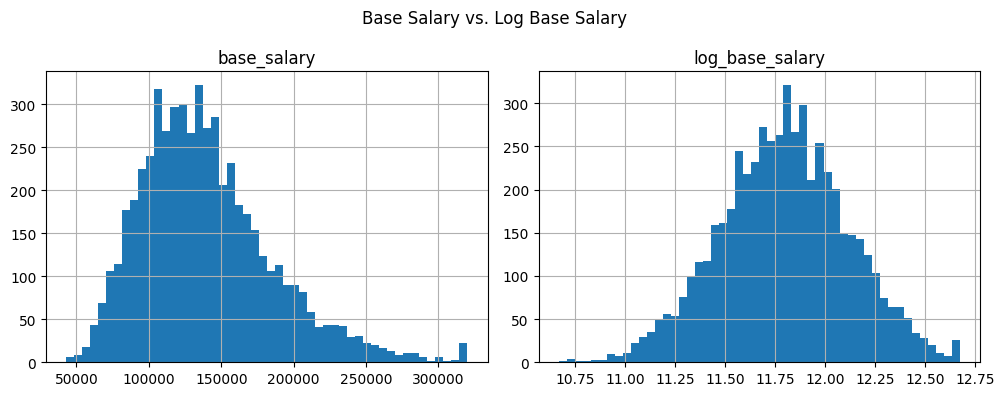

In [28]:
df_copy['log_base_salary'] = np.log1p(df_copy['base_salary'])

df_copy['sqrt_years_experience'] = np.sqrt(df_copy['years_experience'])
df_copy['sqrt_years_at_company'] = np.sqrt(df_copy['years_at_company'])

df_copy[['base_salary', 'log_base_salary']].hist(bins=50, figsize=(10, 4))
plt.suptitle("Base Salary vs. Log Base Salary")
plt.tight_layout()
plt.savefig('../reports/figures/log-normal_salary.png')
plt.show()

In [29]:
import os

os.makedirs('../data/processed', exist_ok=True)

df_copy.to_csv('../data/processed/salary_benchmark_engineered.csv', index=False)

